# Curve-Fitting — the backtest that lies 🎚️
### Tune a moving-average crossover until it shines — does the winner survive out of sample?

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Survives_out_of_sample%3F: Busted](https://img.shields.io/badge/Survives_out_of_sample%3F-Busted-8b949e?style=flat-square)

Give a backtester two dials and a grid, and they will *always* find a setting that looks brilliant on past data. The dangerous question is whether that winning setting keeps working on data it has never seen. This notebook tunes a moving-average crossover the lazy way — pick the best of 93 — and watches what happens next, both on a coin-flip market we build and on real S&P 500.

> 📓 **This is the plain-language layer.** Want the *t*-stats, the shrinkage-vs-grid-size curve and the alpha-vs-beta strip? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> ⚠️ **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from curve_fitting import data, strategy as st

def _have_cache():
    return os.path.exists(data._cache_path(data.DEFAULT_CACHE, "SPY"))

HAVE_REAL = _have_cache()

def real_series():
    px = data.load_real(ticker="SPY", fetch=False)
    asof = px.index.max().to_period("M").to_timestamp()   # drop the partial final month
    return px[px.index < asof]

print("real SPY cache present:", HAVE_REAL)


real SPY cache present: True


## The answer first

| Question | Answer |
|---|---|
| Can you tune a backtest to look great? | **Trivially.** On a *pure random walk* the best of 93 crossovers scored an in-sample Sharpe of **0.94** — a number you'd kill for. |
| Does the winner keep working? | **No.** That same pair earned **-0.05** out of sample (basically zero). The 'edge' was the search fitting noise. |
| But it survived on real SPY, right? | **Only as a disguise.** The tuned rule's out-of-sample Sharpe (0.69) was just the market's — it was long 84% of a bull decade. Strip the market out and it *lost* **6%/yr** versus simply holding. |
| So is the method useless? | **No — it's a detector, not a generator.** When we plant a *real* trend, the winner survives cleanly. Tuning can confirm a signal; it cannot conjure one. |

> A great backtest is the *easiest* thing in finance to manufacture. The whole skill is refusing to be impressed by one.

## 1 · The claim

The pitch is everywhere — in books, courses, and every 'I found a strategy with Sharpe 2' thread:

> *Sweep your strategy's parameters, keep the settings with the best backtest, and trade those. The market rewarded them before; it will reward them again.*

It feels like science: you searched, you measured, you optimised. The strong version says the optimisation **improves** your live results — that the configuration which won the backtest is genuinely better than a random one. If that's true, finding edges is just a matter of grid-searching hard enough.

## 2 · So what?

If tuning worked, two things would follow. First, anyone with a laptop could mine edges to order — and they can't, which is itself a clue. Second, and more practically: a tuned backtest is the single most common reason a strategy looks wonderful on paper and bleeds money live. Knowing *exactly how much* of a glowing backtest is real and how much is the search flattering itself is the difference between an investor and a victim. That gap has a name — **overfitting** — and we can measure it.

## 3 · How would we even know?

One honest protocol, announced before we run it:

1. **Cut the data in half** — an *in-sample* slice to tune on, an *out-of-sample* slice we promise never to peek at while tuning.
2. **Sweep 93 crossovers** on the in-sample half and crown the best one.
3. **Run that exact winner** on the out-of-sample half.
4. **Compare** its in-sample Sharpe to its out-of-sample Sharpe. If the search found a real edge, the two should roughly agree. If it found noise, the out-of-sample number collapses.

The clincher: we run this on a market we *built to have no edge at all* (a random walk). If the winner there 'survives', our test is broken. If it collapses — as it must — we've caught the mirage red-handed. Then we plant a *real* trend and check the test still passes a true signal.

## 4 · The teardown — let's actually look

**First, the trap, on a coin-flip market.** We generate a pure random walk — by construction there is *no* crossover that genuinely works. Then we tune anyway and look at the in-sample winner versus its out-of-sample fate.

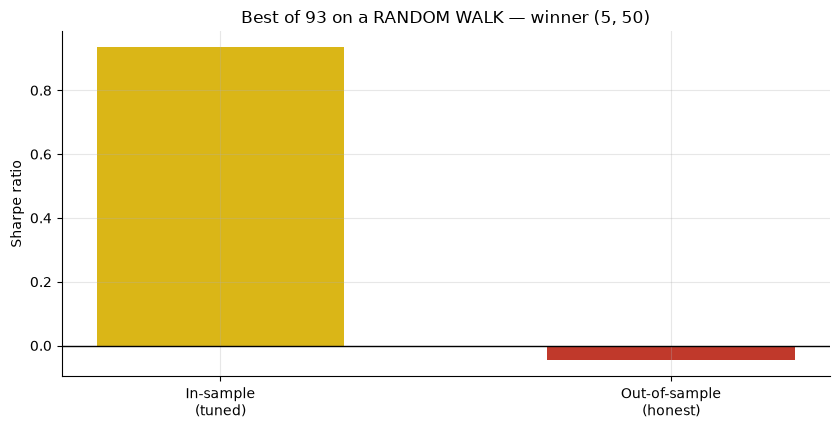

IS Sharpe 0.94  ->  OOS Sharpe -0.05


In [2]:
px_null, _ = data.synthetic_series(n_days=5000, trend_strength=0.0, trend_halflife=80, seed=348)
res_null = st.curve_fit_experiment(px_null, frac_is=0.5)
fig, ax = plt.subplots(figsize=(8.5, 4.4))
ax.bar(['In-sample\n(tuned)', 'Out-of-sample\n(honest)'],
       [res_null['is_sharpe'], res_null['oos_sharpe']], color=[AMBER, RED], width=.55)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('Sharpe ratio')
ax.set_title(f"Best of 93 on a RANDOM WALK — winner {res_null['winner']}")
plt.tight_layout(); plt.show()
print(f"IS Sharpe {res_null['is_sharpe']:.2f}  ->  OOS Sharpe {res_null['oos_sharpe']:+.2f}")

On a market with **nothing in it**, the best of 93 crossovers scored an in-sample Sharpe of ~**0.94** — and then earned ~**-0.05** out of sample. The entire backtest was the search picking whichever pair happened to fit this stretch of noise. There was never anything to find.

**The mirage gets *louder* the harder you search.** Watch the in-sample Sharpe climb as we let the grid grow — while the out-of-sample Sharpe never budges off zero.

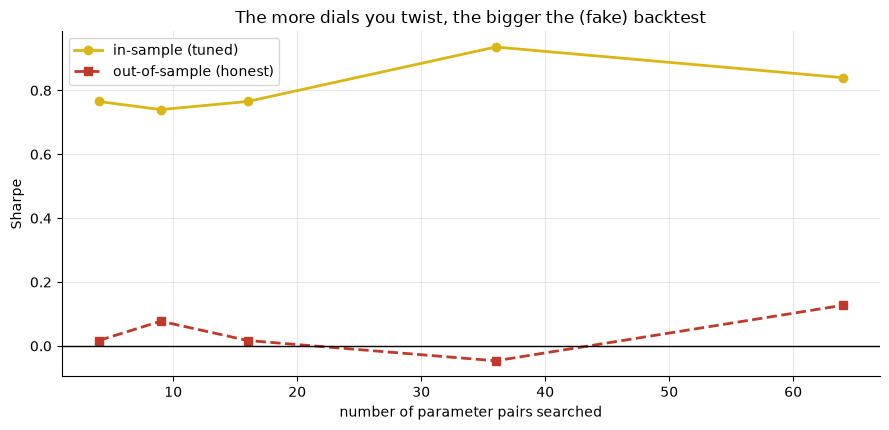

IS by grid size : ['0.77', '0.74', '0.77', '0.94', '0.84']
OOS by grid size: ['+0.02', '+0.08', '+0.02', '-0.05', '+0.13']


In [3]:
gs = st.grid_size_sweep(px_null, frac_is=0.5)
fig, ax = plt.subplots(figsize=(9, 4.4))
ax.plot(gs['n_params'], gs['is_sharpe'], 'o-', c=AMBER, lw=2, label='in-sample (tuned)')
ax.plot(gs['n_params'], gs['oos_sharpe'], 's--', c=RED, lw=2, label='out-of-sample (honest)')
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('number of parameter pairs searched'); ax.set_ylabel('Sharpe')
ax.set_title('The more dials you twist, the bigger the (fake) backtest')
ax.legend(); plt.tight_layout(); plt.show()
print('IS by grid size :', [f'{v:.2f}' for v in gs['is_sharpe']])
print('OOS by grid size:', [f'{v:+.2f}' for v in gs['oos_sharpe']])

Searching more is not *learning* more — it's just buying more lottery tickets and keeping the winner. The in-sample number is the size of your search, not the size of your edge.

**Now the real tape — S&P 500, 1993–2026.** We tune on the first half, then run the winner on the second. Did it survive?

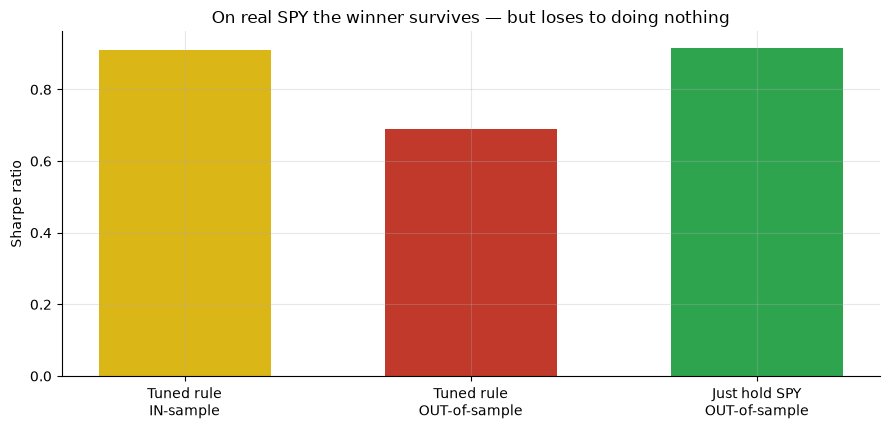

tuned IS 0.91 | tuned OOS 0.69 | buy-and-hold OOS 0.92
tuned rule alpha vs buy-and-hold: -6.1%/yr


In [4]:
if HAVE_REAL:
    px = real_series()
    res = st.curve_fit_experiment(px, frac_is=0.5)
    is_px, oos_px = st.split(px, 0.5)
    a = st.alpha_vs_buyhold(oos_px, *res['winner'])
    is_s, oos_s, bh_s = res['is_sharpe'], res['oos_sharpe'], a['buyhold_sharpe']
    alpha = a['alpha_ann']*100
else:
    is_s, oos_s, bh_s, alpha = 0.91, 0.69, 0.92, -6.12
fig, ax = plt.subplots(figsize=(9, 4.4))
ax.bar(['Tuned rule\nIN-sample', 'Tuned rule\nOUT-of-sample', 'Just hold SPY\nOUT-of-sample'],
       [is_s, oos_s, bh_s], color=[AMBER, RED, GREEN], width=.6)
ax.set_ylabel('Sharpe ratio')
ax.set_title('On real SPY the winner survives — but loses to doing nothing')
plt.tight_layout(); plt.show()
print(f'tuned IS {is_s:.2f} | tuned OOS {oos_s:.2f} | buy-and-hold OOS {bh_s:.2f}')
print(f'tuned rule alpha vs buy-and-hold: {alpha:+.1f}%/yr')

Here's the subtle part. On real SPY the tuned rule's out-of-sample Sharpe (~**0.69**) *didn't* collapse to zero — because the out-of-sample years (2009–2026) were a roaring bull market, and a long/flat rule that's long most of the time just **rides the market**. Compare it to doing nothing: buy-and-hold scored ~**0.92** — *better*. The tuning didn't add an edge; it added **6%/yr of drag** versus simply holding the index.

**The control — does the test still pass a *real* signal?** We plant a genuine slow trend in the synthetic market and re-run. If tuning is pure folly the winner should fail here too; if the test is honest, it should survive.

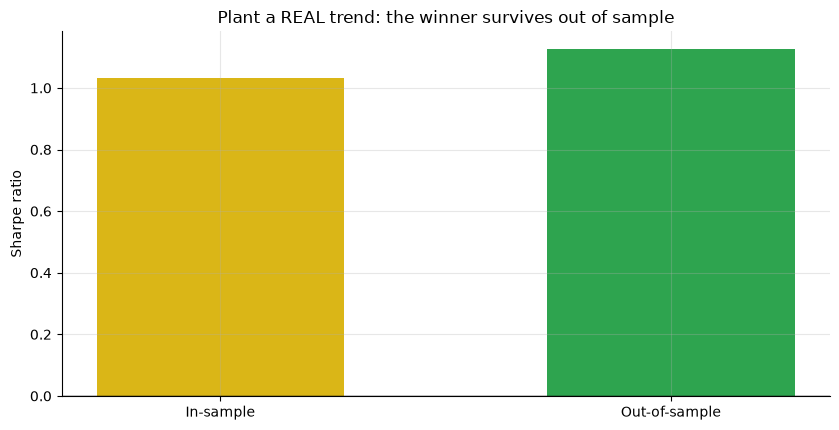

IS 1.03 -> OOS 1.13 (shrinkage -0.10)


In [5]:
px_ctrl, _ = data.synthetic_series(n_days=5000, trend_strength=0.0015, trend_halflife=80, seed=348)
res_ctrl = st.curve_fit_experiment(px_ctrl, frac_is=0.5)
fig, ax = plt.subplots(figsize=(8.5, 4.4))
ax.bar(['In-sample', 'Out-of-sample'],
       [res_ctrl['is_sharpe'], res_ctrl['oos_sharpe']], color=[AMBER, GREEN], width=.55)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('Sharpe ratio')
ax.set_title('Plant a REAL trend: the winner survives out of sample')
plt.tight_layout(); plt.show()
print(f"IS {res_ctrl['is_sharpe']:.2f} -> OOS {res_ctrl['oos_sharpe']:.2f} "
      f"(shrinkage {res_ctrl['shrinkage']:+.2f})")

With a real trend planted, the in-sample winner earns ~**1.03** *and* keeps ~**1.13** out of sample — the gap nearly vanishes. So tuning isn't worthless: it's a **detector**. It confirms an edge that's truly there, and exposes one that isn't. The danger is only when you mistake the search itself for the edge.

## 5 · The verdict

- **Signal — None.** The optimised crossover has no real edge. On a coin-flip market it reverts to noise out of sample; on real SPY its survival is just the market's beta, and its alpha over buy-and-hold is *negative* (-6%/yr).
- **Tradability — Mirage.** You'd underperform a buy-and-hold index fund while paying to trade a pattern fitted to the past. There is nothing to harvest.
- **Does the in-sample winner survive out of sample? — Busted.** The big backtest is the size of your search, not your edge — and it inflates further the more you tune. (A genuinely planted signal *does* survive, which is the proof the method is a detector, not a magician.)

## 6 · Could you actually trade it?

You can absolutely trade a curve-fitted rule — that's the tragedy. It will look fantastic right up to the moment your money is on it, then deliver the out-of-sample number, which here is *worse than the index after costs*. The honest takeaway isn't a tweak to the rule; it's a rule about rules: **hold back data the optimiser never sees, judge the winner only there, and subtract the beta you'd have gotten for free.** Anything a tuned backtest claims beyond that out-of-sample, beta-stripped number is the search admiring its own reflection.

## 7 · Going further 🚪

- **Walk it forward.** A single 50/50 split is the crudest defence. Fork this and run a rolling walk-forward (re-tune every year, trade the next) and watch how much of the mirage survives even that.
- **Deflate the Sharpe.** Bailey & López de Prado's *Deflated Sharpe Ratio* turns the grid-size-vs-IS-Sharpe curve you saw here into a formal correction. Add it and see how big a backtest Sharpe has to be before it's even *interesting*.
- **Crank the dials.** Add a stop-loss, a holding period, a volatility filter — every extra parameter widens the search and inflates the in-sample number further. Re-run the null and measure how fast the mirage grows.

*Think your tuned strategy is the real thing? Fork this, run your parameters on a random walk, and see if the backtest looks any different. If it doesn't, you were curve-fitting.*